## Low-pass Filter 

### Defn of a Low-pass Filter:
A low-pass filter lets low (slow) frequencies pass through while attenuating higher (faster) frequencies. Frequencies below the cutoff frequency lie in the passband, while frequencies above it are in the stopband and are reduced in amplitude.

H(s) = 1/(1 + sRC)


#### Setup for a Mass-Spring-Damper | Mechanical Impedance

Depending on which output we measure, a mass–spring–damper system can behave like a low-pass filter in different ways.

To prevent high-frequency force inputs from strongly affecting the velocity (or displacement) of a mass, we can place a damper in series with the mass:

F_in → [Damper (b)] → [Mass (m)] → v_m

The damper’s force is proportional to relative velocity:
input: F_d = b * dv/dt
output: v_m = m * a_m * dt

The damper responds weakly at low frequencies because the change in velocity is small, producing only a small damping force. At high frequencies (rapid velocity changes), F_d becomes large, effectively attenuating how much motion reaches the mass.

In this way, the series damper acts as a high-frequency isolator, creating a low-pass effect for the mass’s velocity or displacement.

#### Derivation using an RC circuit | Electrical Impedance

 Vin ───R───+─── Vout
            |
           C
            |
           GND


v_out = v_in - RC * d/dt v_out

How it works:
Resistor (R) = job: Draws voltage from current
Ohm's Law: i = V / R
Low-frequency voltage changes → Little voltage drop across R, most of v_in appears at v_out.
High-frequency voltage changes → Will absorb fluctuations in v_in becuase it helps the capacitor create a voltage divider, which regulates the v_out by attenuating rapid changes.

Capacitor (C) = job: Regulates voltage by adjusting current
Capacitor's Law: i = C dV/dt
Low-frequency voltage changes → Impedance becomes very high as it has time to be either fully charged or discharged, so little current flows through C. Input signal is sent to the output signal.
High-frequency voltage changes → Cap is caught in a charging or discharging state, which affects the current supplied back to the circuit. A voltage divider is formed with the R, thus some input signal is lost due to the voltage supplied back to the output by the Cap.

apply step response: v_in -> Vi
v_out = Vi * (1 - e^(-omg*t))
where: omg = 1/RC i.e. the cutoff frequency 

Laplace ->
H(s) = omg / (s + omg)

Difference Equation:
V_n = v_out_n = y_n
v_n = v_in_n = x_n

V_n = beta * V_n-1 + (1 - beta)v_n
 

### Background:
Examples of low-pass filters: 
electronics = RC Circuit, sensor smoothing
optics = Blur the ultra-fine details, reduce the Moire pattern(false color)
mechanics = mass-spring-damper, car suspension
software = a moving average difference equation
economics = a moving average filter
acoustics = stiff physical barrier reflects higher frequencies

A perfect low-pass filter is infinite in time and shaped like a sinc. A rectangular pass-band in the frequency domain transforms into the time domain, with the inverse-Fourier transforms, and can be described by the sinc function. 
Thus, h(t) = 2 * fc * sinc(2 * fc * t)


### Possible Design Considerations:
1. Cutoff Frequency
-- To reduce noise → FFT the signal to determine the maximum useful frequency, adjust as needed to smooth the signal
-- To remove aliasing → Cutoff at the Nyquist frequency = half the sampling frequency
2. Roll-off rate: can roll-off faster with a higher degree
-- at a second-order degree, resonance is possible
-- at a higher-order degree, more complexity enters and a greater chance of instability
3. Phase Delay: consider lag
-- By adding lag, we are messing with the stability of the system as the phase margin changes.
-- Be careful not to add a nonlinear delay that may distort frequencies of signals.


### Anti-aliasing Low-Pass Filters
Notes on aliasing from Resource 2: "Basics of Anti-Aliasing Low-Pass Filters..." by Art Pini.
Aliasing is the loss of signal information through digital under-sampling an analog input. When the measured signal has a faster frequency than the digital sampling rate, the measurement reads incorrect signals. The sampling rate of the sensor must be 2x the Nyquist frequency of the measured signal.
To prevent aliasing, we can low-pass filter the input to the system such that only signals that are slow enough for the measurement sensors to sample are sent through to the system. Anti-aliasing filters are low-pass analog circuits that should not amplify, or distort the signal(first order RC circuits <- correction, there are more options such as active, digitally controllable, and switched capacitors).

Quick notes on designing an anti-aliasing low-pass filter: signals are no longer passed at -3 db, so set the cutoff frequency here. Give an engineering factor of 2.5 to 4 times the Nyquist frequency to collect data samples at. The three most common types of low-pass filters are Butterworth(amplitude accuracy), Chebyshev(if sampling rate is approx. the signal bandwidth, steep roll-off), Bessel (signal fidelity, linear time delay).


### Digital Filters: Low-pass and Moving Average(FIR, IIR) in the digital world

A low-pass filter can be implemented as a moving average in discrete-time to reduce noise.

These filters can be implemented as either a Finite Impluse Response(FIR), or an Infinite Impulse Response(IIR).

FIR filters only depend on inputs(current and past), where as IIR filters depend on inputs and past outputs, so it receives feedback. FIR filters are always stable because they only contain zeros. IIR filters could introduce instability because they add poles to the system dynamics. For our filter to be able to view past inputs, we must delay the signal. In the FIR case, this shift is linear thus we do not distort wavelengths. IIR filters require less memory as they more efficiently use fewer coefficients.

An implementation of an FIR filter:
y(n) = b0*x(n) + b1*x(n-1) + ... + bm*x(n-m).

An implementation of an IIR filter:
y(n) = b0*x(n) + b1*x(n-1) + ... + bm*x(n-m) + a1*y(n-1) + ... + aJ*(n-J).

In [1]:
# Compare the bode plots of filters with different RC values
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

In [12]:
# Structure: H(s) = 1 / (RC * s + 1)

R = 1e3  # Resistance in ohms
R_high = 10e3  # High resistance in ohms
C = 1e-6  # Capacitance in farads
C_high = 5e-6  # High capacitance in farads

# Transfer function coefficients
num = [1]
den = [R * C, 1]
den_high_r = [R_high * C, 1]
den_high_c = [R * C_high, 1]

# Build TF
sys = signal.TransferFunction(num, den)
sys_high_r = signal.TransferFunction(num, den_high_r)
sys_high_c = signal.TransferFunction(num, den_high_c)

# Simulate the Bode plot
w, mag, phase = signal.bode(sys)
w_high_r, mag_high_r, phase_high_r = signal.bode(sys_high_r)
w_high_c, mag_high_c, phase_high_c = signal.bode(sys_high_c)

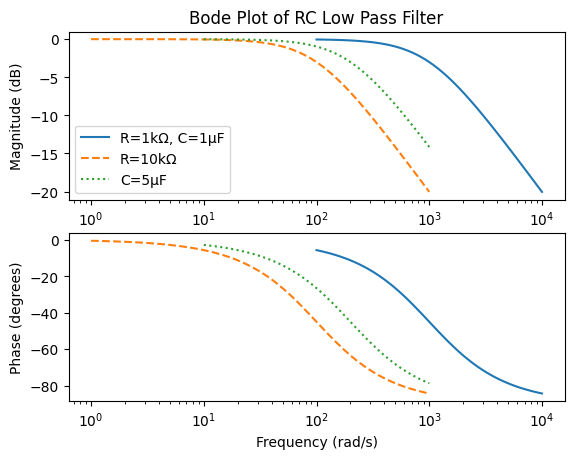

In [13]:
plt.subplot(2,1,1)
plt.semilogx(w, mag)
plt.semilogx(w_high_r, mag_high_r, linestyle='--')
plt.semilogx(w_high_c, mag_high_c, linestyle=':')
plt.title('Bode Plot of RC Low Pass Filter')
plt.ylabel('Magnitude (dB)')
plt.legend(['R=1kΩ, C=1μF', 'R=10kΩ', 'C=5μF'])

plt.subplot(2,1,2)
plt.semilogx(w, phase)
plt.semilogx(w_high_r, phase_high_r, linestyle='--')
plt.semilogx(w_high_c, phase_high_c, linestyle=':')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (degrees)')
plt.show()


### Observations
Increasing either the resistance or capacitance in the circuit lowers the cutoff frequency. This has several noticeable effects on the filter's behavior: 
-- Narrower passband: The range of frequencies that can pass through the filter without significant attenuation is reduced. Filters out more high-frequency signals
-- Greater attenuation of higher frequencies: Signals above the new, lower cutoff frequency are filtered out more strongly.
-- Slight effect on low frequencies: While the filter primarily targets higher frequencies, the overall amplitude of the output signal can decrease slightly due to the increased impedance.

From the transfer function perspective, the output is inversely related to the product of
R and C. In other words, increasing either component reduces the overall response of the circuit at higher frequencies. Each component contributes proportionally and equally to this effect, emphasizing the role of the RC time constant in shaping the filter’s behavior.

In the phase plot, the overall shape of the response remains consistent across variations in R or C. However, the curve shifts toward lower frequencies as the RC values increase, mirroring the changes observed in the magnitude plot. This alignment demonstrates that both magnitude and phase respond predictably to changes in the circuit’s time constant, confirming the fundamental relationship between component values and filter behavior.


### Conclusion
Low-pass filters let low-frequency signals pass through, while attenuating fast high-frequencies. These types of filters are very common in many different types of system domains. When designing these filters to fit into the system, one must ask about details regarding the cutoff frequency, the roll-off rate, and the allowable phase delay/lag in the system. Low-pass filters are critical for solving the common aliasing problem when a system has frequencies too fast for the sampling rate of a measuring device. Beyond analog implementations, low-pass behavior can be replicated digitally using FIR and IIR filters, offering flexibility for modern signal processing applications. Lastly, we also explored the RC low-pass filter and analyzed its Bode plot to develop an intuition for how varying the resistance and capacitance affects the circuit’s magnitude and phase response. This practical examination reinforces the fundamental relationship between a filter’s components and its frequency-domain behavior.


### Future Areas of Interest:
1. The dynamic Prototype Filter
2. the sinc function
3. Hanning Windows
4. ARM Cortex-M SIMD for filtering operation


### Resources:
1. https://en.wikipedia.org/wiki/Low-pass_filter
2. https://www.digikey.com/en/articles/the-basics-of-anti-aliasing-low-pass-filters
3. https://www.advsolned.com/difference-between-iir-and-fir-filters-a-practical-design-guide/